In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
start = '2012-01-01'
end = '2022-12-21'

stock = 'GOOG'

data = yf.download(stock,start,end)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
data.reset_index(inplace=True)

In [5]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.495003,16.562926,16.171750,16.185882,147611217
1,2012-01-04,16.566145,16.614980,16.376260,16.485581,114989399
2,2012-01-05,16.336349,16.459304,16.267435,16.413692,131808205
3,2012-01-06,16.113497,16.360893,16.107794,16.339821,108119746
4,2012-01-09,15.430305,16.038633,15.399813,16.026237,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.860703,96.761702,93.497166,95.089622,26452900
2757,2022-12-15,90.770065,93.586726,90.003699,93.099038,28298800
2758,2022-12-16,90.431679,91.317483,89.585687,90.770072,48485500


In [6]:
ma_100_days = data.Close.rolling(100).mean()

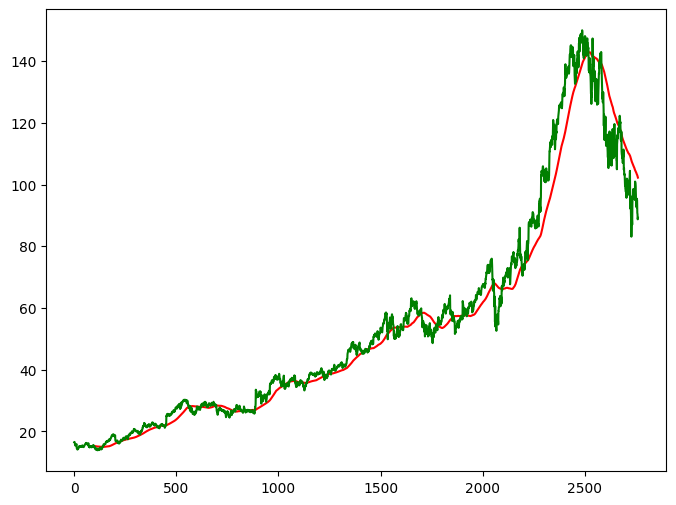

In [7]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [8]:
ma_200_days = data.Close.rolling(200).mean()

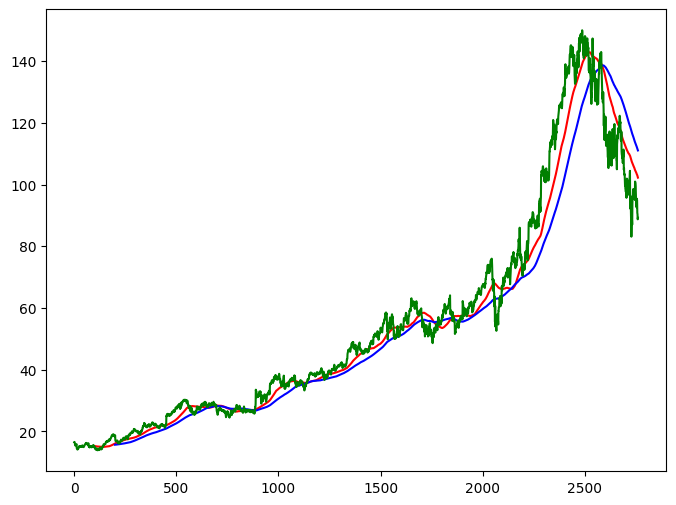

In [9]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [13]:
data.dropna(inplace=True)

In [16]:
data_train = pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [17]:
data_train.shape[0]

2208

In [18]:
data_test.shape[0]

553

In [20]:
from sklearn.preprocessing import MinMaxScaler

# ✅ Correct: feature_range is a parameter, so use '='
scaler = MinMaxScaler(feature_range=(0, 1))  

In [21]:
data_train_scale = scaler.fit_transform(data_train)

In [22]:
x = []
y=[]

for i in range (100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [24]:
x,y = np.array(x), np.array(y)

In [25]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, 
               input_shape=(x.shape[1], 1))) 
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True)) 
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))  
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))  

In [32]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [33]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
66/66 [==============================] - 56s 709ms/step - loss: 0.0290
Epoch 2/50
66/66 [==============================] - 39s 593ms/step - loss: 0.0075
Epoch 3/50
66/66 [==============================] - 35s 529ms/step - loss: 0.0052
Epoch 4/50
66/66 [==============================] - 40s 602ms/step - loss: 0.0055
Epoch 5/50
66/66 [==============================] - 40s 608ms/step - loss: 0.0049
Epoch 6/50
66/66 [==============================] - 40s 608ms/step - loss: 0.0052
Epoch 7/50
66/66 [==============================] - 40s 609ms/step - loss: 0.0048
Epoch 8/50
66/66 [==============================] - 39s 589ms/step - loss: 0.0050
Epoch 9/50
66/66 [==============================] - 40s 607ms/step - loss: 0.0038
Epoch 10/50
66/66 [==============================] - 40s 604ms/step - loss: 0.0041
Epoch 11/50
66/66 [==============================] - 40s 599ms/step - loss: 0.0041
Epoch 12/50
66/66 [==============================] - 40s 599ms/step - loss: 0.0041
Epoch 13/50
6

In [34]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 100, 50)           10400     
                                                                 
 dropout_3 (Dropout)         (None, 100, 50)           0         
                                                                 
 lstm_4 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_4 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_5 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_5 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_6 (LSTM)               (None, 120)              

In [35]:
pas_100_days =  data_train.tail(100)

In [36]:
data_test = pd.concat([pas_100_days, data_test], ignore_index= True)

In [38]:
data_test_scale = scaler.fit_transform(data_test)

In [40]:
x = []
y=[]

for i in range (100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x,y = np.array(x), np.array(y)

In [41]:
y_predict = model.predict(x)

18/18 [==============================] - 2s 79ms/step


In [43]:
1/scaler.scale_

array([82.32407379])

In [46]:
y_predict = y_predict * scaler.scale_ 

In [48]:
y = y*scaler.scale_

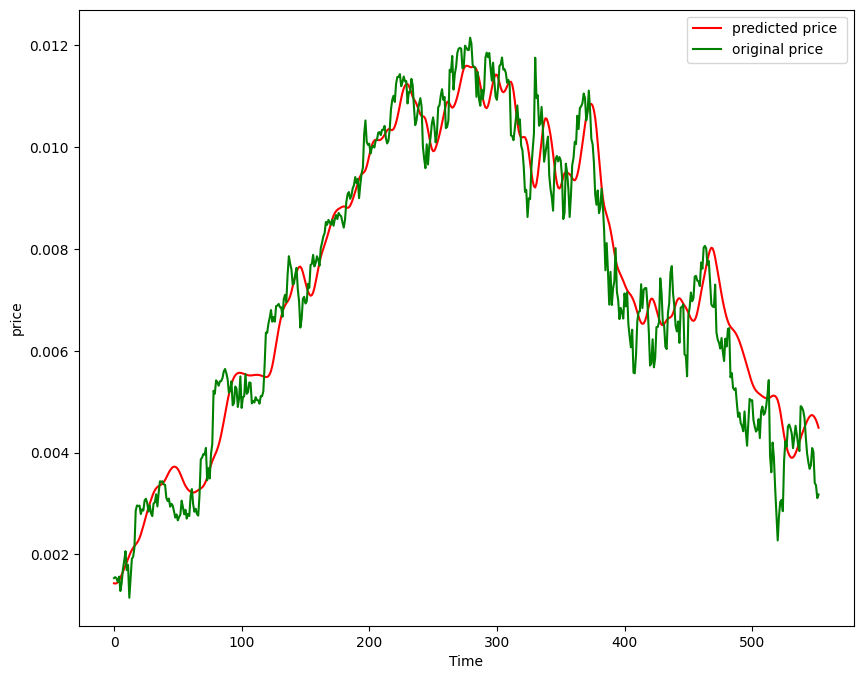

In [49]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'predicted price ')
plt.plot(y, 'g' , label = 'original price')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend()
plt.show()

In [52]:
import tensorflow as tf  # <-- Add this import

# Save
model.save("Stock_predictions_Model.keras", save_format="tf")

# Load
loaded_model = tf.keras.models.load_model("Stock_predictions_Model.keras")